# Preprocessing

In [1]:
import subprocess

In [6]:
def create_chunks(file, out, n):
    with open(file, 'r') as f_in, open(out, 'w') as f_out:
        for line in f_in:
            seq = line.strip()
            for i in range(len(seq) - n + 1):
                f_out.write(seq[i:i+n] + "\n")

def pipeline(train, alphabet, test, n, r):
    chunk_train = f"chunks_n_{n}_r_{r}.train"
    create_chunks(train, chunk_train, n)
    cmd = [
        "java", "-jar", "negsel2.jar",
        "-alphabet", f"{alphabet}",
        "-self", f"{chunk_train}", 
        "-n", str(n), 
        "-r", str(r), 
        "-c", "-l"
    ]
    results = []
    with open(test, 'r') as f:
        for line in f:
            seq = line.strip()
            chunks = [seq[i:i+n] for i in range(len(seq) - n + 1)]
            result = subprocess.run(cmd, input="\n".join(chunks), capture_output=True, text=True)
            scores = [float(s) for s in result.stdout.splitlines() if s.strip()]
            avg_score = sum(scores) / len(scores) if scores else 0.0
            results.append(avg_score)
    return results

# Evaluation

## Parameter Search

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [12]:
parameters = [
    (8, 3),
    (8, 4),
    (8, 5),
    (8, 6),   
    (10, 3),
    (10, 4),
    (10, 5),
    (10, 6),
    (12, 5),
    (12, 6),
    (12, 7),
    (12, 8)
]

In [13]:
with open("syscalls/snd-cert/snd-cert.1.labels", "r") as f:
    y_true = [int(line.strip()) for line in f]

Testing
  n=8
  r=3
Testing
  n=8
  r=4
Testing
  n=8
  r=5
Testing
  n=8
  r=6
Testing
  n=10
  r=3
Testing
  n=10
  r=4
Testing
  n=10
  r=5
Testing
  n=10
  r=6
Testing
  n=12
  r=5
Testing
  n=12
  r=6
Testing
  n=12
  r=7
Testing
  n=12
  r=8


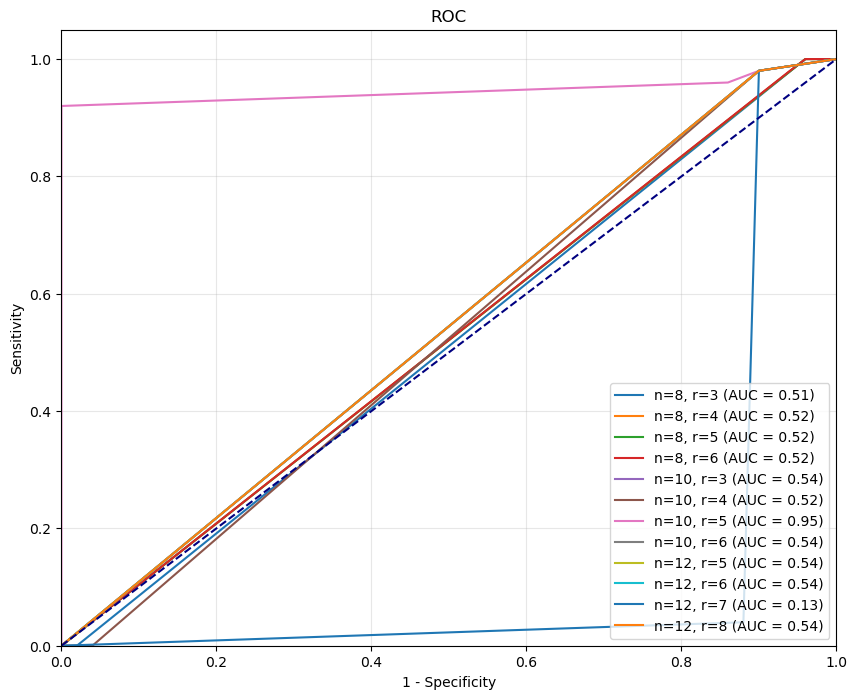

In [14]:
plt.figure(figsize=(10, 8))

for n,r in parameters:
    print(f"Testing\n  n={n}\n  r={r}")
    y_scores = pipeline(
        train="syscalls/snd-cert/snd-cert.train",
        alphabet="syscalls/snd-cert/snd-cert.alpha", 
        test="syscalls/snd-cert/snd-cert.1.test",
        n=n,
        r=r
    )

    x, y, _ = roc_curve(y_true, y_scores)
    auc_score = auc(x, y)
    plt.plot(x, y, label=f'n={n}, r={r} (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], color='navy', linestyle='--') 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity')
plt.ylabel('Sensitivity')
plt.title('ROC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Looks like $n=10$ and $r=5$ are good parameters

## Verification

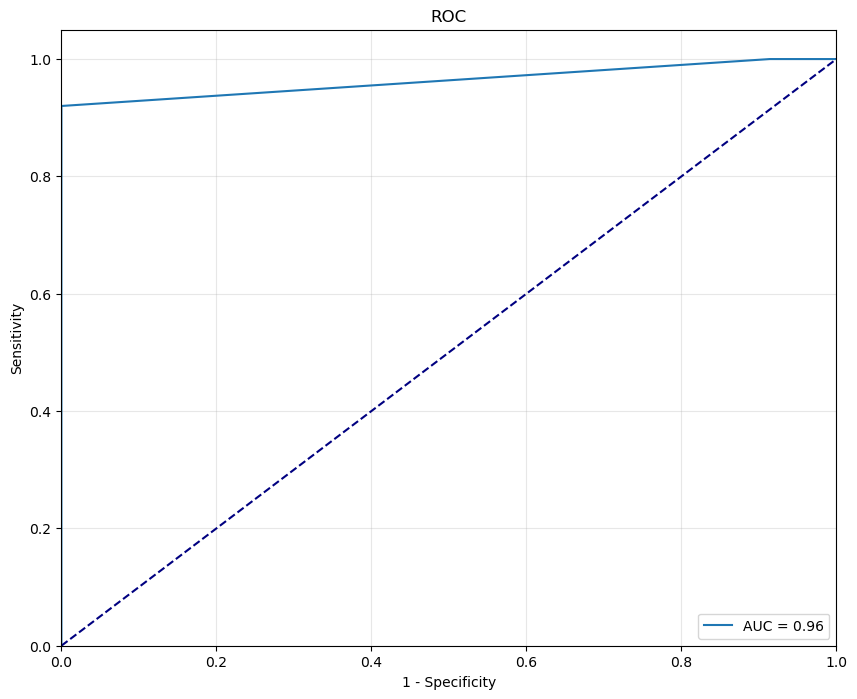

In [7]:
with open("syscalls/snd-cert/snd-cert.2.labels", "r") as f:
    y_true = [int(line.strip()) for line in f]

plt.figure(figsize=(10, 8))

y_scores = pipeline(
        train="syscalls/snd-cert/snd-cert.train",
        alphabet="syscalls/snd-cert/snd-cert.alpha", 
        test="syscalls/snd-cert/snd-cert.2.test",
        n=10,
        r=5
    )
x, y, _ = roc_curve(y_true, y_scores)
auc_score = auc(x, y)
plt.plot(x, y, label=f'AUC = {auc_score:.2f}')

plt.plot([0, 1], [0, 1], color='navy', linestyle='--') 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity')
plt.ylabel('Sensitivity')
plt.title('ROC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

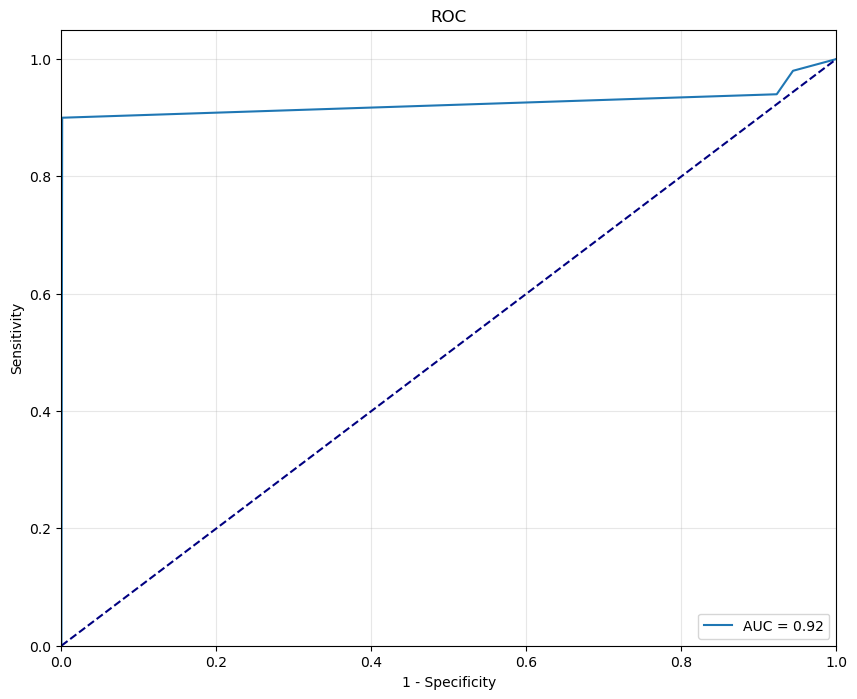

In [8]:
with open("syscalls/snd-cert/snd-cert.3.labels", "r") as f:
    y_true = [int(line.strip()) for line in f]

plt.figure(figsize=(10, 8))

y_scores = pipeline(
        train="syscalls/snd-cert/snd-cert.train",
        alphabet="syscalls/snd-cert/snd-cert.alpha", 
        test="syscalls/snd-cert/snd-cert.3.test",
        n=10,
        r=5
    )
x, y, _ = roc_curve(y_true, y_scores)
auc_score = auc(x, y)
plt.plot(x, y, label=f'AUC = {auc_score:.2f}')

plt.plot([0, 1], [0, 1], color='navy', linestyle='--') 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity')
plt.ylabel('Sensitivity')
plt.title('ROC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Other Dataset

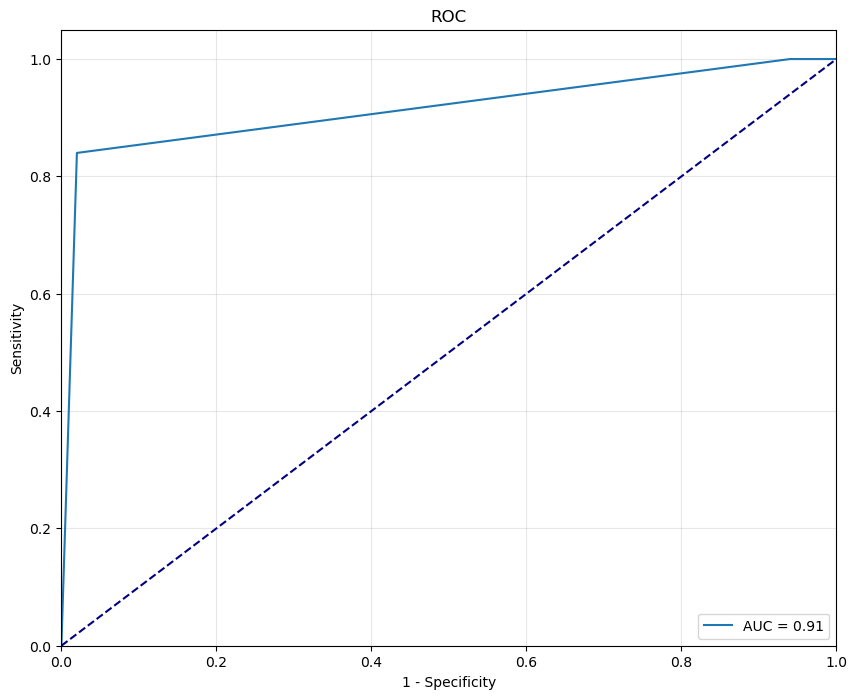

In [9]:
with open("syscalls/snd-unm/snd-unm.1.labels", "r") as f:
    y_true = [int(line.strip()) for line in f]

plt.figure(figsize=(10, 8))

y_scores = pipeline(
        train="syscalls/snd-unm/snd-unm.train",
        alphabet="syscalls/snd-unm/snd-unm.alpha", 
        test="syscalls/snd-unm/snd-unm.1.test",
        n=10,
        r=5
    )
x, y, _ = roc_curve(y_true, y_scores)
auc_score = auc(x, y)
plt.plot(x, y, label=f'AUC = {auc_score:.2f}')

plt.plot([0, 1], [0, 1], color='navy', linestyle='--') 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity')
plt.ylabel('Sensitivity')
plt.title('ROC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()